## 데이터

In [184]:
import pandas as pd
import numpy as np

SVI = pd.read_csv("samsung_SVI.csv", index_col=0, parse_dates=True)
SVI = SVI.resample('ME').last()
SVI.tail()

,삼성전자
날짜,
2025-10-31,39.44957
2025-11-30,34.46382
2025-12-31,26.94231
2026-01-31,49.93977
2026-02-28,50.98125


In [185]:
adj_close = pd.read_csv("수정주가.csv", index_col=0,parse_dates=True)
adj_close = adj_close.resample('ME').last()
monthly_return = adj_close.pct_change()

/var/folders/qj/vy5ztdf564jg38f9lktwgj6m0000gn/T/ipykernel_16125/2161739657.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  monthly_return = adj_close.pct_change()


In [186]:
samsung = monthly_return[['삼성전자']]

In [187]:
samsung = samsung['2016-02-29':'2025-09-30']
samsung

,삼성전자
Date,
2016-02-29,0.024348
2016-03-31,0.113752
2016-04-30,-0.051067
2016-05-31,0.037751
2016-06-30,0.102941
...,...
2025-05-31,0.012613
2025-06-30,0.064057
2025-07-31,0.193980


___
## SVI데이터를 로그차분

In [188]:
ln_SVI = np.log(SVI).diff().dropna()

In [189]:
ln_SVI

ln_SVI = ln_SVI.rename(columns={'삼성전자': 'ln_SVI'})
ln_SVI = ln_SVI['2016-02-29':'2025-09-30']


___
## 계절성 제거

In [190]:
import statsmodels.api as sm

# 월 정보
month = ln_SVI.index.month

# 월 더미 (1월 기준)
month_dummies = pd.get_dummies(month, prefix='M', drop_first=True)
month_dummies.index = ln_SVI.index

# 디자인 매트릭스
X = sm.add_constant(month_dummies).astype(float)

In [191]:
# 컬럼별로 회귀
ASVI = pd.DataFrame(index=ln_SVI.index, columns=ln_SVI.columns, dtype=float)

for col in ln_SVI.columns:
    y = ln_SVI[col].astype(float)

    # 결측 제거
    mask = y.notna()

    if mask.sum() <= X.shape[1]:
        continue  # 표본 부족하면 스킵

    model = sm.OLS(y.loc[mask], X.loc[mask]).fit()

    # 계절성 제거된 ASVI = 잔차
    ASVI.loc[mask, col] = model.resid

ASVI.head()

,ln_SVI
날짜,
2016-02-29,0.012268
2016-03-31,-0.044778
2016-04-30,0.018673
2016-05-31,-0.210907
2016-06-30,0.380949


___
## 메인 회귀

In [192]:
factors = pd.read_csv('factors.csv', index_col=0, parse_dates=True)
factors = factors.resample("ME").last()
factors = factors.pct_change()
factors = factors['2016-02-29':'2025-09-30']

factors_df = pd.concat([factors, ln_SVI], axis=1)

In [193]:
factors_df

,KOSPI,SMB,HML,MOM,RF,ln_SVI
2016-02-29,0.002406,0.006981,0.074147,-0.071034,-0.012121,-0.178089
2016-03-31,0.041317,0.030118,0.022534,-0.030738,-0.012270,0.057025
2016-04-30,-0.000852,0.034303,-0.004935,-0.025707,0.000000,-0.031028
2016-05-31,-0.005391,0.008606,-0.031571,0.035927,-0.031056,-0.299317
2016-06-30,-0.006580,0.004509,-0.009071,0.003709,-0.121795,0.382566
...,...,...,...,...,...,...
2025-05-31,0.055175,-0.017765,0.061506,0.047865,-0.044280,-0.274962
2025-06-30,0.138649,-0.067961,0.028903,0.011075,-0.011583,0.387474
2025-07-31,0.056562,-0.043851,-0.025323,-0.064316,-0.019531,0.447614
2025-08-31,-0.018312,-0.002987,-0.001854,-0.008658,0.007968,-0.377528


In [194]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# samsung이 DataFrame이라고 가정: '삼성전자' 컬럼 사용
# 1. 필요한 열만 모아서 하나의 회귀용 데이터프레임 생성
reg_df = pd.concat([
    samsung[['삼성전자']],
    factors_df[['RF', 'KOSPI', 'SMB', 'HML', 'MOM', 'ln_SVI']]
], axis=1)

# 2. 종속변수와 독립변수 생성
reg_df['y'] = reg_df['삼성전자'] - reg_df['RF']

reg_df['MKT'] = reg_df['KOSPI'] - reg_df['RF']
reg_df['SMB'] = reg_df['SMB']
reg_df['HML'] = reg_df['HML']
reg_df['MOM'] = reg_df['MOM']
reg_df['ln_SVI'] = reg_df['ln_SVI']

# 3. inf -> NaN 처리 후 결측 제거
reg_df = reg_df.replace([np.inf, -np.inf], np.nan)

# 회귀에 필요한 열만 남기기
reg_df = reg_df[['y', 'MKT', 'SMB', 'HML', 'MOM', 'ln_SVI']].dropna()

# 4. 회귀용 y, X 분리
y = reg_df['y']
X = reg_df[['MKT', 'SMB', 'HML', 'MOM', 'ln_SVI']]
X = sm.add_constant(X, has_constant='add')

# 5. OLS + Newey-West(HAC)
model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.793
Model:                            OLS   Adj. R-squared:                  0.783
Method:                 Least Squares   F-statistic:                     165.9
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           1.56e-49
Time:                        19:19:35   Log-Likelihood:                 185.46
No. Observations:                 116   AIC:                            -358.9
Df Residuals:                     110   BIC:                            -342.4
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0065      0.004      1.447      0.1

In [195]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

# 1. 필요한 데이터만 결합
reg_df = pd.concat([
    samsung[['삼성전자']],
    factors_df[['RF', 'KOSPI', 'SMB', 'HML', 'MOM', 'ln_SVI']]
], axis=1)

# 2. 종속변수 / 독립변수 생성
reg_df['y'] = reg_df['삼성전자'] - reg_df['RF']         # 삼성전자 초과수익률
reg_df['MKT'] = reg_df['KOSPI'] - reg_df['RF']         # 시장초과수익률

# 3. inf / nan 제거
reg_df = reg_df.replace([np.inf, -np.inf], np.nan)
reg_df = reg_df[['y', 'MKT', 'SMB', 'HML', 'MOM', 'ln_SVI']].dropna()

# 4. y, X 설정
y = reg_df['y']
X = reg_df[['MKT', 'SMB', 'HML', 'MOM', 'ln_SVI']]
X = sm.add_constant(X, has_constant='add')

# 5. 12개월 롤링 회귀
W = 36
rol = RollingOLS(endog=y, exog=X, window=W).fit()

# 6. 결과 확인
print(rol.params.tail())     # 각 시점별 계수
print(rol.tvalues.tail())    # 각 시점별 t값

               const       MKT       SMB       HML       MOM    ln_SVI
2025-05-31 -0.003983  0.905740 -0.036404  0.113984 -0.059155  0.067813
2025-06-30 -0.004438  0.843279 -0.011812  0.071962 -0.079311  0.058137
2025-07-31 -0.000091  0.838226 -0.155648 -0.011613 -0.239445  0.073546
2025-08-31  0.001144  0.829535 -0.154189 -0.021814 -0.231401  0.069839
2025-09-30  0.005948  0.798038 -0.122961 -0.050478 -0.136927  0.094252
               const       MKT       SMB       HML       MOM    ln_SVI
2025-05-31 -0.451366  9.953573 -0.123635  0.502001 -0.260184  1.654762
2025-06-30 -0.491542  8.826998 -0.038908  0.312033 -0.335980  1.414179
2025-07-31 -0.009184  6.874952 -0.490198 -0.044428 -0.989315  1.697591
2025-08-31  0.116164  6.771784 -0.488029 -0.084013 -0.956753  1.685825
2025-09-30  0.546825  4.954402 -0.353210 -0.177406 -0.501527  2.090751


<Axes: >

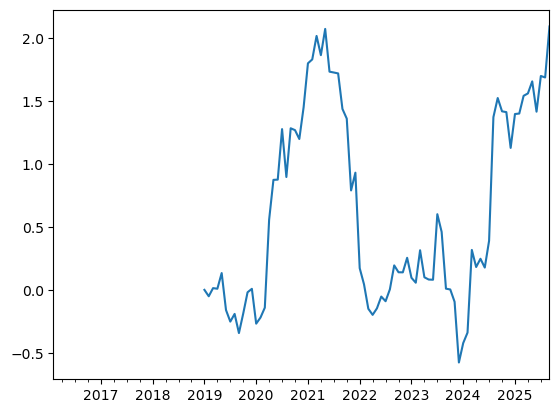

In [196]:
rol.tvalues['ln_SVI'].plot()

In [197]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS

# 1) 데이터 결합
reg_df = pd.concat([
    samsung[['삼성전자']],
    factors_df[['RF', 'KOSPI', 'SMB', 'HML', 'MOM', 'ln_SVI']]
], axis=1).copy()

# 2) 이번 달 초과수익률
reg_df['ret_excess'] = reg_df['삼성전자'] - reg_df['RF']

# 3) 다음 달 초과수익률(예측 대상)
reg_df['y_fwd'] = reg_df['ret_excess'].shift(-1)

# 4) 이번 달 시점에 관측 가능한 설명변수
reg_df['MKT'] = reg_df['KOSPI'] - reg_df['RF']

# 5) 회귀용 데이터 정리
reg_df = reg_df[['y_fwd', 'MKT', 'SMB', 'HML', 'MOM', 'ln_SVI']]
reg_df = reg_df.replace([np.inf, -np.inf], np.nan).dropna()

# -----------------------------
# [A] 전체 표본 예측회귀 (OLS)
# -----------------------------
y = reg_df['y_fwd']
X = reg_df[['MKT', 'SMB', 'HML', 'MOM', 'ln_SVI']]
X = sm.add_constant(X, has_constant='add')

model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
print(model.summary())

# -----------------------------
# [B] 12개월 롤링 예측회귀
# -----------------------------
W = 36
rol = RollingOLS(endog=y, exog=X, window=W).fit()

print("\n[최근 5개 시점 롤링 계수]")
print(rol.params.tail())

print("\n[최근 5개 시점 롤링 t값]")
print(rol.tvalues.tail())

                            OLS Regression Results                            
Dep. Variable:                  y_fwd   R-squared:                       0.211
Model:                            OLS   Adj. R-squared:                  0.175
Method:                 Least Squares   F-statistic:                     18.18
Date:                Tue, 10 Mar 2026   Prob (F-statistic):           4.38e-13
Time:                        19:19:35   Log-Likelihood:                 106.55
No. Observations:                 115   AIC:                            -201.1
Df Residuals:                     109   BIC:                            -184.6
Df Model:                           5                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0077      0.013      0.590      0.5

In [198]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# =========================================================
# 1. 데이터 준비
# =========================================================
def prepare_monthly_data(samsung, factors_df):
    """
    samsung: DataFrame, 반드시 '삼성전자' 컬럼 포함
    factors_df: DataFrame, 반드시
        ['RF', 'KOSPI', 'SMB', 'HML', 'MOM', 'ln_SVI'] 컬럼 포함
    """
    df = pd.concat([
        samsung[['삼성전자']],
        factors_df[['RF', 'KOSPI', 'SMB', 'HML', 'MOM', 'ln_SVI']]
    ], axis=1).copy()

    # 초과수익률
    df['ret_excess'] = df['삼성전자'] - df['RF']

    # 시장 초과수익률
    df['MKT'] = df['KOSPI'] - df['RF']

    # 다음 달 초과수익률 (예측 대상)
    df['y_fwd'] = df['ret_excess'].shift(-1)

    # 정리
    df = df.replace([np.inf, -np.inf], np.nan)
    return df


# =========================================================
# 2. 성과지표 함수
# =========================================================
def performance_stats(ret_series, periods_per_year=12):
    """
    ret_series: 총수익률(total return) 기준 Series
    """
    r = ret_series.dropna().copy()
    if len(r) == 0:
        return pd.Series(dtype=float)

    wealth = (1 + r).cumprod()
    n = len(r)

    cagr = wealth.iloc[-1] ** (periods_per_year / n) - 1
    ann_vol = r.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = (r.mean() / r.std(ddof=1)) * np.sqrt(periods_per_year) if r.std(ddof=1) != 0 else np.nan

    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    mdd = drawdown.min()

    hitrate = (r > 0).mean()
    avg_monthly = r.mean()

    out = pd.Series({
        'CAGR': cagr,
        'Ann.Vol': ann_vol,
        'Sharpe': sharpe,
        'MDD': mdd,
        'HitRate': hitrate,
        'Avg.Monthly.Return': avg_monthly,
        'Months': n
    })
    return out


# =========================================================
# 3. 전략 alpha 계산 (사후 성과평가용)
# =========================================================
def carhart_alpha(excess_ret, df_full):
    """
    excess_ret: 전략 초과수익률 Series
    df_full: 원본 데이터프레임 (MKT, SMB, HML, MOM 필요)
    """
    reg_df = pd.concat([
        excess_ret.rename('strategy_excess'),
        df_full[['MKT', 'SMB', 'HML', 'MOM']]
    ], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    if len(reg_df) < 24:
        return None

    y = reg_df['strategy_excess']
    X = sm.add_constant(reg_df[['MKT', 'SMB', 'HML', 'MOM']], has_constant='add')

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
    return model


# =========================================================
# 4. 롤링 예측 회귀 기반 백테스트
# =========================================================
def run_predictive_backtest(
    samsung,
    factors_df,
    window=12,
    threshold=0.0,
    long_short=False,
    cost_per_1x_turnover=0.0015,
    feature_cols=None
):
    """
    window: 롤링 추정기간 (예: 12개월)
    threshold:
        예측값 기준치
        long_short=False 이면 pred > threshold 일 때만 롱
        long_short=True 이면
            pred > threshold  -> +1
            pred < -threshold -> -1
            그 외            -> 0

    cost_per_1x_turnover:
        turnover 1.0당 비용.
        예: 0 -> 1 매수면 turnover=1
            +1 -> -1 전환이면 turnover=2
    """

    if feature_cols is None:
        feature_cols = ['MKT', 'SMB', 'HML', 'MOM', 'ln_SVI']

    df = prepare_monthly_data(samsung, factors_df)

    # 회귀에 필요한 열만 유지
    keep_cols = ['삼성전자', 'RF', 'KOSPI', 'ret_excess', 'y_fwd'] + feature_cols
    df = df[keep_cols].replace([np.inf, -np.inf], np.nan).copy()

    # 저장용
    pred = pd.Series(index=df.index, dtype=float)
    weight = pd.Series(index=df.index, dtype=float)
    coef_store = pd.DataFrame(index=df.index, columns=['const'] + feature_cols, dtype=float)

    # -----------------------------------------------------
    # row t의 feature로 row t의 y_fwd (= t+1 수익률) 예측
    # 학습은 t-1까지의 과거 데이터만 사용
    # -----------------------------------------------------
    for t in range(window, len(df) - 1):
        train = df.iloc[t-window:t].copy()
        train = train[['y_fwd'] + feature_cols].dropna()

        if len(train) < window:
            continue

        y_train = train['y_fwd']
        X_train = sm.add_constant(train[feature_cols], has_constant='add')

        model = sm.OLS(y_train, X_train).fit()

        # t 시점 정보로 t+1 예측
        x_now = df.iloc[[t]][feature_cols].copy()
        if x_now.isna().any(axis=1).iloc[0]:
            continue

        x_now = sm.add_constant(x_now, has_constant='add')

        pred_t1 = model.predict(x_now).iloc[0]
        pred.iloc[t] = pred_t1

        # 계수 저장
        coef_store.loc[df.index[t], model.params.index] = model.params.values

        # 다음 달 보유 비중 결정
        if long_short:
            if pred_t1 > threshold:
                weight.iloc[t+1] = 1.0
            elif pred_t1 < -threshold:
                weight.iloc[t+1] = -1.0
            else:
                weight.iloc[t+1] = 0.0
        else:
            if pred_t1 > threshold:
                weight.iloc[t+1] = 1.0
            else:
                weight.iloc[t+1] = 0.0

    # 비어있는 부분 0 처리
    weight = weight.fillna(0.0)

    # -----------------------------------------------------
    # 수익률 계산
    # -----------------------------------------------------
    out = df.copy()
    out['pred_excess_next'] = pred
    out['weight'] = weight

    # 전략 초과수익률 = weight * (주식 - RF)
    out['strategy_excess_gross'] = out['weight'] * out['ret_excess']

    # turnover
    out['turnover'] = out['weight'].diff().abs()
    out['turnover'] = out['turnover'].fillna(out['weight'].abs())

    # 거래비용 반영
    out['cost'] = cost_per_1x_turnover * out['turnover']
    out['strategy_excess_net'] = out['strategy_excess_gross'] - out['cost']

    # 총수익률(total return)로 환산
    # 현금 보유 시 RF를 받는 구조
    out['strategy_total_gross'] = out['RF'] + out['strategy_excess_gross']
    out['strategy_total_net'] = out['RF'] + out['strategy_excess_net']

    # 비교군
    out['bh_stock_total'] = out['삼성전자']          # 삼성전자 Buy&Hold 총수익률
    out['bh_cash_total'] = out['RF']               # 현금
    out['bh_kospi_total'] = out['KOSPI']           # KOSPI 총수익률

    # 누적자산
    out['nav_strategy_gross'] = (1 + out['strategy_total_gross'].fillna(0)).cumprod()
    out['nav_strategy_net'] = (1 + out['strategy_total_net'].fillna(0)).cumprod()
    out['nav_stock_bh'] = (1 + out['bh_stock_total'].fillna(0)).cumprod()
    out['nav_cash_bh'] = (1 + out['bh_cash_total'].fillna(0)).cumprod()
    out['nav_kospi_bh'] = (1 + out['bh_kospi_total'].fillna(0)).cumprod()

    # -----------------------------------------------------
    # 성과 요약
    # -----------------------------------------------------
    perf = pd.DataFrame({
        'Strategy Gross': performance_stats(out['strategy_total_gross']),
        'Strategy Net': performance_stats(out['strategy_total_net']),
        'Samsung BH': performance_stats(out['bh_stock_total']),
        'Cash BH': performance_stats(out['bh_cash_total']),
        'KOSPI BH': performance_stats(out['bh_kospi_total'])
    })

    # -----------------------------------------------------
    # 사후 alpha 평가
    # -----------------------------------------------------
    alpha_model = carhart_alpha(out['strategy_excess_net'], prepare_monthly_data(samsung, factors_df))

    return out, perf, coef_store, alpha_model


# =========================================================
# 5. 실행 예시
# =========================================================

# 기본: 12개월 롤링, long-only, 예측값이 0보다 클 때만 투자
bt, perf, coef_path, alpha_model = run_predictive_backtest(
    samsung=samsung,
    factors_df=factors_df,
    window=12,
    threshold=0.0,
    long_short=False,
    cost_per_1x_turnover=0.0015,   # turnover 1당 15bp
    feature_cols=['MKT', 'SMB', 'HML', 'MOM', 'ln_SVI']
)

print("=== 성과표 ===")
print(perf)

print("\n=== 최근 10개 행 ===")
print(bt[['삼성전자', 'RF', 'ret_excess', 'pred_excess_next', 'weight',
          'turnover', 'cost', 'strategy_total_net', 'nav_strategy_net']].tail(10))

if alpha_model is not None:
    print("\n=== Strategy Net Carhart Alpha ===")
    print(alpha_model.summary())
else:
    print("\nAlpha 회귀를 돌리기엔 표본이 부족합니다.")

=== 성과표 ===
                    Strategy Gross  Strategy Net  Samsung BH     Cash BH  \
CAGR                      0.184507      0.176162    0.143251    0.045637   
Ann.Vol                   0.276524      0.276572    0.255841    0.273100   
Sharpe                    0.748478      0.722540    0.650152    0.295570   
MDD                      -0.402146     -0.405765   -0.375447   -0.673575   
HitRate                   0.474138      0.474138    0.534483    0.379310   
Avg.Monthly.Return        0.017248      0.016653    0.013861    0.006727   
Months                  116.000000    116.000000  116.000000  116.000000   

                      KOSPI BH  
CAGR                  0.059537  
Ann.Vol               0.175703  
Sharpe                0.417567  
MDD                  -0.346163  
HitRate               0.568966  
Avg.Monthly.Return    0.006114  
Months              116.000000  

=== 최근 10개 행 ===
                삼성전자        RF  ret_excess  pred_excess_next  weight  \
2024-12-31 -0.018450  0.0

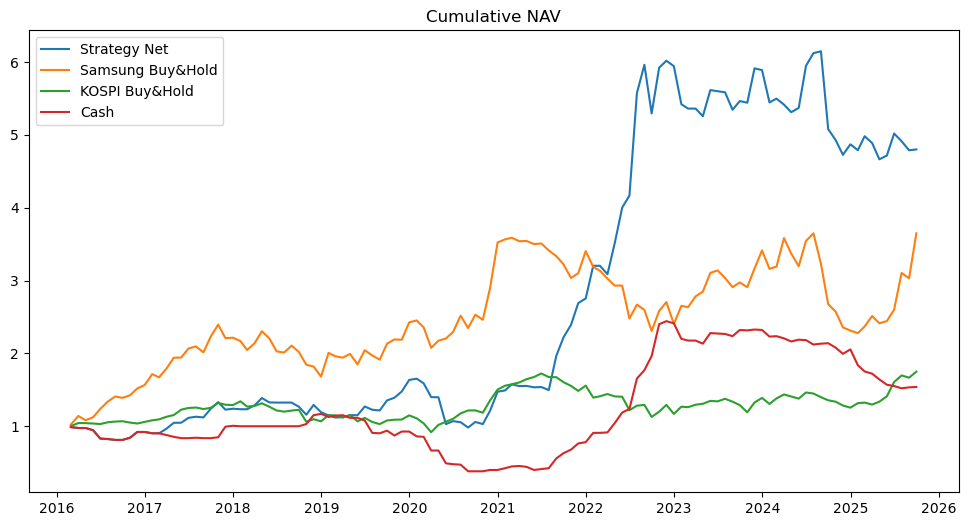

In [199]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(bt.index, bt['nav_strategy_net'], label='Strategy Net')
plt.plot(bt.index, bt['nav_stock_bh'], label='Samsung Buy&Hold')
plt.plot(bt.index, bt['nav_kospi_bh'], label='KOSPI Buy&Hold')
plt.plot(bt.index, bt['nav_cash_bh'], label='Cash')
plt.legend()
plt.title('Cumulative NAV')
plt.show()

In [200]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

# =========================================================
# 1. 데이터 준비
# =========================================================
def prepare_monthly_data(samsung, factors_df):
    """
    samsung: DataFrame, 반드시 '삼성전자' 컬럼 포함
    factors_df: DataFrame, 반드시
        ['RF', 'KOSPI', 'SMB', 'HML', 'MOM', 'ln_SVI'] 컬럼 포함
    """
    df = pd.concat([
        samsung[['삼성전자']],
        factors_df[['RF', 'KOSPI', 'SMB', 'HML', 'MOM', 'ln_SVI']]
    ], axis=1).copy()

    # 초과수익률
    df['ret_excess'] = df['삼성전자'] - df['RF']

    # 시장 초과수익률
    df['MKT'] = df['KOSPI'] - df['RF']

    # 다음 달 초과수익률 (예측 대상)
    df['y_fwd'] = df['ret_excess'].shift(-1)

    # 정리
    df = df.replace([np.inf, -np.inf], np.nan)
    return df


# =========================================================
# 2. 성과지표 함수
# =========================================================
def performance_stats(ret_series, periods_per_year=12):
    """
    ret_series: 총수익률(total return) 기준 Series
    """
    r = ret_series.dropna().copy()
    if len(r) == 0:
        return pd.Series(dtype=float)

    wealth = (1 + r).cumprod()
    n = len(r)

    cagr = wealth.iloc[-1] ** (periods_per_year / n) - 1
    ann_vol = r.std(ddof=1) * np.sqrt(periods_per_year)
    sharpe = (r.mean() / r.std(ddof=1)) * np.sqrt(periods_per_year) if r.std(ddof=1) != 0 else np.nan

    running_max = wealth.cummax()
    drawdown = wealth / running_max - 1
    mdd = drawdown.min()

    hitrate = (r > 0).mean()
    avg_monthly = r.mean()

    out = pd.Series({
        'CAGR': cagr,
        'Ann.Vol': ann_vol,
        'Sharpe': sharpe,
        'MDD': mdd,
        'HitRate': hitrate,
        'Avg.Monthly.Return': avg_monthly,
        'Months': n
    })
    return out


# =========================================================
# 3. 전략 alpha 계산 (사후 성과평가용)
# =========================================================
def carhart_alpha(excess_ret, df_full):
    """
    excess_ret: 전략 초과수익률 Series
    df_full: 원본 데이터프레임 (MKT, SMB, HML, MOM 필요)
    """
    reg_df = pd.concat([
        excess_ret.rename('strategy_excess'),
        df_full[['MKT', 'SMB', 'HML', 'MOM']]
    ], axis=1).replace([np.inf, -np.inf], np.nan).dropna()

    if len(reg_df) < 24:
        return None

    y = reg_df['strategy_excess']
    X = sm.add_constant(reg_df[['MKT', 'SMB', 'HML', 'MOM']], has_constant='add')

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 12})
    return model


# =========================================================
# 4. 롤링 예측 회귀 기반 백테스트
# =========================================================
def run_predictive_backtest(
    samsung,
    factors_df,
    window=12,
    threshold=0.0,
    long_short=False,
    cost_per_1x_turnover=0.0015,
    feature_cols=None
):
    """
    window: 롤링 추정기간 (예: 12개월)
    threshold:
        예측값 기준치
        long_short=False 이면 pred > threshold 일 때만 롱
        long_short=True 이면
            pred > threshold  -> +1
            pred < -threshold -> -1
            그 외            -> 0

    cost_per_1x_turnover:
        turnover 1.0당 비용.
        예: 0 -> 1 매수면 turnover=1
            +1 -> -1 전환이면 turnover=2
    """

    if feature_cols is None:
        feature_cols = ['MKT', 'SMB', 'HML', 'MOM', 'ln_SVI']

    df = prepare_monthly_data(samsung, factors_df)

    # 회귀에 필요한 열만 유지
    keep_cols = ['삼성전자', 'RF', 'KOSPI', 'ret_excess', 'y_fwd'] + feature_cols
    df = df[keep_cols].replace([np.inf, -np.inf], np.nan).copy()

    # 저장용
    pred = pd.Series(index=df.index, dtype=float)
    weight = pd.Series(index=df.index, dtype=float)
    coef_store = pd.DataFrame(index=df.index, columns=['const'] + feature_cols, dtype=float)

    # -----------------------------------------------------
    # row t의 feature로 row t의 y_fwd (= t+1 수익률) 예측
    # 학습은 t-1까지의 과거 데이터만 사용
    # -----------------------------------------------------
    for t in range(window, len(df) - 1):
        train = df.iloc[t-window:t].copy()
        train = train[['y_fwd'] + feature_cols].dropna()

        if len(train) < window:
            continue

        y_train = train['y_fwd']
        X_train = sm.add_constant(train[feature_cols], has_constant='add')

        model = sm.OLS(y_train, X_train).fit()

        # t 시점 정보로 t+1 예측
        x_now = df.iloc[[t]][feature_cols].copy()
        if x_now.isna().any(axis=1).iloc[0]:
            continue

        x_now = sm.add_constant(x_now, has_constant='add')

        pred_t1 = model.predict(x_now).iloc[0]
        pred.iloc[t] = pred_t1

        # 계수 저장
        coef_store.loc[df.index[t], model.params.index] = model.params.values

        # 다음 달 보유 비중 결정
        if long_short:
            if pred_t1 > threshold:
                weight.iloc[t+1] = 1.0
            elif pred_t1 < -threshold:
                weight.iloc[t+1] = -1.0
            else:
                weight.iloc[t+1] = 0.0
        else:
            if pred_t1 > threshold:
                weight.iloc[t+1] = 1.0
            else:
                weight.iloc[t+1] = 0.0

    # 비어있는 부분 0 처리
    weight = weight.fillna(0.0)

    # -----------------------------------------------------
    # 수익률 계산
    # -----------------------------------------------------
    out = df.copy()
    out['pred_excess_next'] = pred
    out['weight'] = weight

    # 전략 초과수익률 = weight * (주식 - RF)
    out['strategy_excess_gross'] = out['weight'] * out['ret_excess']

    # turnover
    out['turnover'] = out['weight'].diff().abs()
    out['turnover'] = out['turnover'].fillna(out['weight'].abs())

    # 거래비용 반영
    out['cost'] = cost_per_1x_turnover * out['turnover']
    out['strategy_excess_net'] = out['strategy_excess_gross'] - out['cost']

    # 총수익률(total return)로 환산
    # 현금 보유 시 RF를 받는 구조
    out['strategy_total_gross'] = out['RF'] + out['strategy_excess_gross']
    out['strategy_total_net'] = out['RF'] + out['strategy_excess_net']

    # 비교군
    out['bh_stock_total'] = out['삼성전자']          # 삼성전자 Buy&Hold 총수익률
    out['bh_cash_total'] = out['RF']               # 현금
    out['bh_kospi_total'] = out['KOSPI']           # KOSPI 총수익률

    # 누적자산
    out['nav_strategy_gross'] = (1 + out['strategy_total_gross'].fillna(0)).cumprod()
    out['nav_strategy_net'] = (1 + out['strategy_total_net'].fillna(0)).cumprod()
    out['nav_stock_bh'] = (1 + out['bh_stock_total'].fillna(0)).cumprod()
    out['nav_cash_bh'] = (1 + out['bh_cash_total'].fillna(0)).cumprod()
    out['nav_kospi_bh'] = (1 + out['bh_kospi_total'].fillna(0)).cumprod()

    # -----------------------------------------------------
    # 성과 요약
    # -----------------------------------------------------
    perf = pd.DataFrame({
        'Strategy Gross': performance_stats(out['strategy_total_gross']),
        'Strategy Net': performance_stats(out['strategy_total_net']),
        'Samsung BH': performance_stats(out['bh_stock_total']),
        'Cash BH': performance_stats(out['bh_cash_total']),
        'KOSPI BH': performance_stats(out['bh_kospi_total'])
    })

    # -----------------------------------------------------
    # 사후 alpha 평가
    # -----------------------------------------------------
    alpha_model = carhart_alpha(out['strategy_excess_net'], prepare_monthly_data(samsung, factors_df))

    return out, perf, coef_store, alpha_model


# =========================================================
# 5. 실행 예시
# =========================================================

# 기본: 12개월 롤링, long-only, 예측값이 0보다 클 때만 투자
bt, perf, coef_path, alpha_model = run_predictive_backtest(
    samsung=samsung,
    factors_df=factors_df,
    window=12,
    threshold=0.0,
    long_short=False,
    cost_per_1x_turnover=0.0015,   # turnover 1당 15bp
    feature_cols=['MKT', 'SMB', 'HML', 'MOM']
)

print("=== 성과표 ===")
print(perf)

print("\n=== 최근 10개 행 ===")
print(bt[['삼성전자', 'RF', 'ret_excess', 'pred_excess_next', 'weight',
          'turnover', 'cost', 'strategy_total_net', 'nav_strategy_net']].tail(10))

if alpha_model is not None:
    print("\n=== Strategy Net Carhart Alpha ===")
    print(alpha_model.summary())
else:
    print("\nAlpha 회귀를 돌리기엔 표본이 부족합니다.")

=== 성과표 ===
                    Strategy Gross  Strategy Net  Samsung BH     Cash BH  \
CAGR                      0.145985      0.138952    0.143251    0.045637   
Ann.Vol                   0.279764      0.279789    0.255841    0.273100   
Sharpe                    0.621937      0.599697    0.650152    0.295570   
MDD                      -0.482593     -0.494954   -0.375447   -0.673575   
HitRate                   0.439655      0.439655    0.534483    0.379310   
Avg.Monthly.Return        0.014500      0.013982    0.013861    0.006727   
Months                  116.000000    116.000000  116.000000  116.000000   

                      KOSPI BH  
CAGR                  0.059537  
Ann.Vol               0.175703  
Sharpe                0.417567  
MDD                  -0.346163  
HitRate               0.568966  
Avg.Monthly.Return    0.006114  
Months              116.000000  

=== 최근 10개 행 ===
                삼성전자        RF  ret_excess  pred_excess_next  weight  \
2024-12-31 -0.018450  0.0

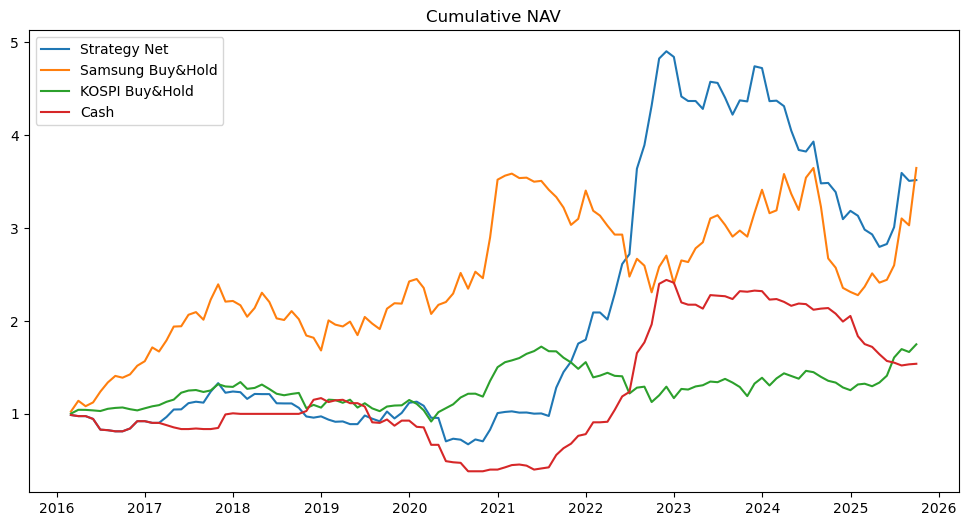

In [201]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(bt.index, bt['nav_strategy_net'], label='Strategy Net')
plt.plot(bt.index, bt['nav_stock_bh'], label='Samsung Buy&Hold')
plt.plot(bt.index, bt['nav_kospi_bh'], label='KOSPI Buy&Hold')
plt.plot(bt.index, bt['nav_cash_bh'], label='Cash')
plt.legend()
plt.title('Cumulative NAV')
plt.show()